CG converged successfully.


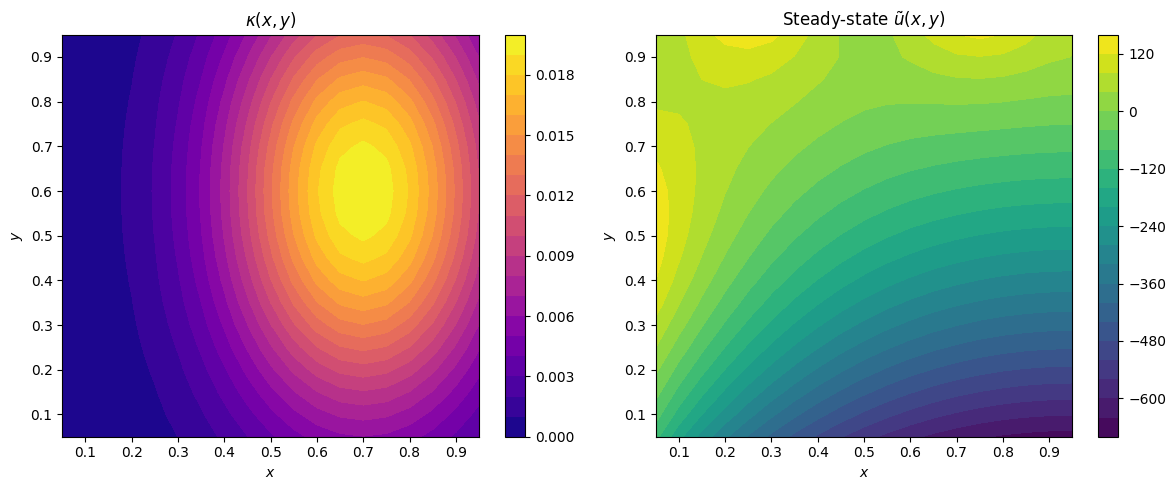

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import cg

# ============================================================
# PARAMETERS
# ============================================================
alp = 0.005
Nx, Ny = 19, 19
L = 1.0

# ============================================================
# GRIDS (interior points only)
# ============================================================
x = np.linspace(0, L, Nx + 2)[1:Nx+1]
y = np.linspace(0, L, Ny + 2)[1:Ny+1]
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)  # shape (Ny, Nx)

kappa = 0.02 * np.exp(-((X - 0.7)**2 / 0.09 + (Y - 0.6)**2 / 0.25))

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================
BCL_D = 0.5 - 0.5 * np.cos(2 * np.pi * y)       # Left,   Dirichlet, shape (Ny,)
BCR_N = 0.0 * np.ones(Ny)                         # Right,  Neumann  , shape (Ny,)
BCB_N = -0.3 * np.ones(Nx)                        # Bottom, Neumann  , shape (Nx,)
BCT_D = 0.5 + 0.5 * np.sin(4 * np.pi * x - 0.5 * np.pi)  # Top, Dirichlet, shape (Nx,)

# ============================================================
# 1D LAPLACIAN MATRIX BUILDER
# ============================================================
def laplace_mat_1d(n, h, bc_first, bc_last):
    """
    Build a 1D tridiagonal Laplacian (n x n) with BC modifications.

    Interior stencil: [1, -2, 1] / h²

    bc_first / bc_last are dicts with keys:
        'type': 'dirichlet' or 'neumann'
        'val' : the scalar BC value

    Dirichlet: remove the off-diagonal (ghost node absorbed into RHS later).
               Row is set to [−2, 1, 0, ...] / h² with no left neighbour.
    Neumann  : use one-sided ghost-point: du/dn = val →
               ghost = real_neighbour − 2h·val  →  stencil becomes [2, -2] / h²
               and RHS gets −2·val/h contribution.
    """
    e = np.ones(n)
    mat = diags([e, -2*e, e], [-1, 0, 1], shape=(n, n), format='lil')

    rhs_bc = np.zeros(n)

    # --- first row (i=0) ---
    if bc_first['type'] == 'dirichlet':
        mat[0, 1] = 1.0          # keep right neighbour
        # left neighbour doesn't exist (boundary); no change needed to mat[0,0]
        # value moved to RHS at assembly time
    elif bc_first['type'] == 'neumann':
        mat[0, 1] = 2.0          # ghost point folds in: [2, -2] stencil
        rhs_bc[0] = -2.0 * bc_first['val'] / h

    # --- last row (i=n-1) ---
    if bc_last['type'] == 'dirichlet':
        mat[n-1, n-2] = 1.0      # keep left neighbour
    elif bc_last['type'] == 'neumann':
        mat[n-1, n-2] = 2.0      # ghost point folds in
        rhs_bc[n-1] = -2.0 * bc_last['val'] / h

    mat = mat.tocsr() / h**2
    return mat, rhs_bc / h  # note rhs_bc already divided by h above

# ============================================================
# BUILD Lx AND Ly
# ============================================================
# x-direction: left=Dirichlet, right=Neumann (∂u/∂x = 0)
Lx, rhs_x = laplace_mat_1d(Nx, dx,
                             bc_first={'type': 'dirichlet', 'val': None},
                             bc_last= {'type': 'neumann',   'val': 0.0})

# y-direction: bottom=Neumann (∂u/∂y = −0.3), top=Dirichlet
Ly, rhs_y = laplace_mat_1d(Ny, dy,
                             bc_first={'type': 'neumann',   'val': -0.3},
                             bc_last= {'type': 'dirichlet', 'val': None})

# ============================================================
# 2D LAPLACIAN VIA KRONECKER PRODUCT
# ============================================================
# U is stored row-major: row = y-index, col = x-index
# L2D @ u_flat = (Iy⊗Lx + Ly⊗Ix) @ u_flat
Ix = eye(Nx, format='csr')
Iy = eye(Ny, format='csr')
L2D = kron(Iy, Lx) + kron(Ly, Ix)

# ============================================================
# RIGHT-HAND SIDE
# ============================================================
# Start from -kappa (flattened row-major to match meshgrid shape)
rhs = -kappa.flatten()   # shape (Nx*Ny,)

# --- Dirichlet corrections (move known boundary values to RHS) ---
# Left boundary (x=0): affects first column of each row → DOF j*Nx + 0
for j in range(Ny):
    rhs[j * Nx + 0] -= BCL_D[j] / dx**2

# Top boundary (y=L): affects last row → DOF (Ny-1)*Nx + i
for i in range(Nx):
    rhs[(Ny-1) * Nx + i] -= BCT_D[i] / dy**2

# --- Neumann corrections (from rhs_bc vectors built in laplace_mat_1d) ---
# Right Neumann (x=L): rhs_x[Nx-1] carries the flux term, applies to each row
for j in range(Ny):
    rhs[j * Nx + (Nx-1)] += rhs_x[Nx-1]

# Bottom Neumann (y=0): rhs_y[0] carries the flux term, applies to each column
for i in range(Nx):
    rhs[0 * Nx + i] += rhs_y[0]

# ============================================================
# SOLVE WITH CONJUGATE GRADIENT (as required by the assignment)
# ============================================================
U_flat, info = cg(alp * L2D, rhs, tol=1e-10, maxiter=10000)

if info == 0:
    print("CG converged successfully.")
else:
    print(f"CG did not converge (info={info})")

USS = U_flat.reshape(Ny, Nx)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cf1 = axes[0].contourf(X, Y, kappa, levels=20, cmap='plasma')
axes[0].set_title(r'$\kappa(x,y)$')
axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$y$')
plt.colorbar(cf1, ax=axes[0])

cf2 = axes[1].contourf(X, Y, USS, levels=20, cmap='viridis')
axes[1].set_title(r'Steady-state $\tilde{u}(x,y)$')
axes[1].set_xlabel(r'$x$'); axes[1].set_ylabel(r'$y$')
plt.colorbar(cf2, ax=axes[1])

plt.tight_layout()
plt.show()